# Advanced Machine Learning (CS60073)
## **Assignment 2:** Gaussian Processes, Latent Variable Models, and Variational Inference (Total Marks: 100)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

## Part A — Gaussian Process Regression

### 1. **(10 marks)** Implement Gaussian Process (GP) regression with an RBF kernel from scratch. Show predictive mean and 95% credible intervals on noisy samples from
$$ f(x) = sin(3x) + 0.5cos(5x), x ∈ [0, 2π] $$

**Gaussian Process Regression with RBF Kernel**

*Step 1:* Define the true function

$$
f(x)=\sin(3x)+0.5\cos(5x)
$$

*Step 2:* Define the RBF kernel

$$
k(X_1,X_2)=\sigma_f^2
\exp\left(-\frac{(X_1-X_2)^2}{2l^2}\right)
$$

*Step 3:* Generate \(50\) equally spaced training points in \([0,2\pi]\).

$$
X_{\text{train}}=\operatorname{linspace}(0,2\pi,50)
$$

Compute the true values

$$
y_{\text{true}}=f(X_{\text{train}})
$$

and add Gaussian noise

$$
y_{\text{train}}
=
y_{\text{true}}+\sigma_n\epsilon,
\qquad
\epsilon\sim\mathcal N(0,I)
$$

with \($\sigma_n=0.25$\).

*Step 4:* Generate \(500\) equally spaced test points in \([0,$2\pi$]\).

$$
X_{\text{test}}=\operatorname{linspace}(0,2\pi,500)
$$

*Step 5:* Set the initial GP hyperparameters

$$
l=0.25,\qquad
\sigma_f=1.0,\qquad
\sigma_n=0.25
$$

*Step 6:* Compute the covariance matrices

$$
K=K(X_{\text{train}},X_{\text{train}})
$$

$$
K_*=K(X_{\text{train}},X_{\text{test}})
$$

$$
K_{**}=K(X_{\text{test}},X_{\text{test}})
$$

*Step 7:* Add observation noise to the training covariance matrix

$$
C_N=K+\sigma_n^2I
$$

*Step 8:* Compute the predictive mean

$$
\mu_*
=
K_*^TC_N^{-1}y_{\text{train}}
$$

Use `np.linalg.solve` instead of explicitly computing \($C_N^{-1}$\).

*Step 9:* Compute the predictive covariance

$$
\Sigma_*
=
K_{**}-K_*^TC_N^{-1}K_*
$$

*Step 10:* Extract the predictive variance and standard deviation

$$
\sigma_*^2=\operatorname{diag}(\Sigma_*)
$$

$$
\sigma_*=\sqrt{\max(\sigma_*^2,0)}
$$

*Step 11:* Compute the approximate 95% credible interval

$$
\text{Lower}=\mu_*-2\sigma_*
$$

$$
\text{Upper}=\mu_*+2\sigma_*
$$

*Step 12:* Plot the noisy training observations, true function, GP predictive mean, and the 95% credible interval.


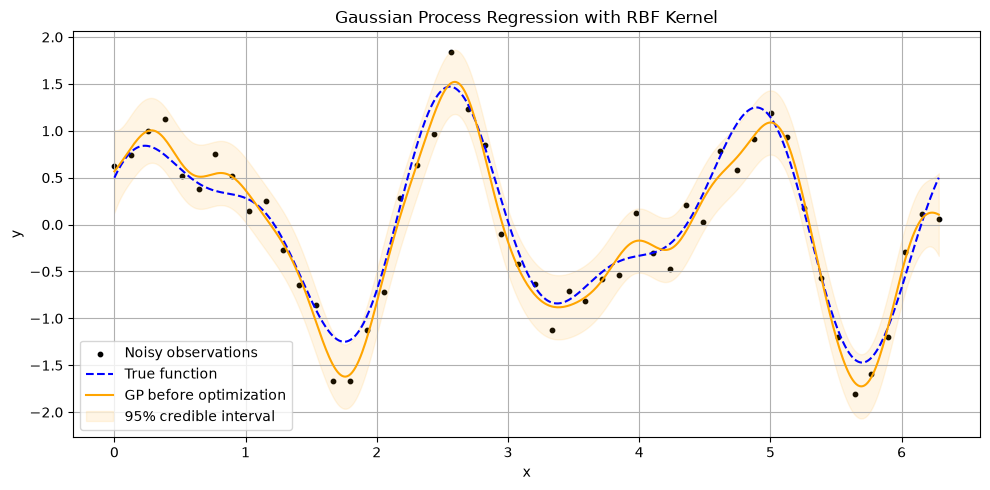

In [2]:
# True function
def f(x):
    return np.sin(3*x) + 0.5 * np.cos(5*x)

# RBF kernel
def rbf(X1, X2, length_scale = 0.5, sigma_f = 1.0):
    X1 = np.asarray(X1).reshape(-1, 1)
    X2 = np.asarray(X2).reshape(-1, 1)
    sq_dist = np.square(X1 - X2.T)
    return sigma_f**2 * np.exp(-sq_dist / (2 * length_scale**2))

# Noisy training data
n_samples = 50
X_train = np.linspace(0, 2 * np.pi, n_samples)
y_true = f(X_train)
noise_std = 0.25
y_train = y_true + noise_std * np.random.randn(n_samples)

# Test data
n_test_samples = 500
X_test = np.linspace(0, 2 * np.pi, n_test_samples)

# GP hyperparams
length_scale = 0.25
sigma_f = 1.0
sigma_n = noise_std

def gp_predict(X_train, y_train, X_test, length_scale, sigma_f, sigma_n):
    """
    GP Prediction
    """
    # Covariance matrices
    K = rbf(X_train, X_train, length_scale, sigma_f)
    K_star = rbf(X_train, X_test, length_scale, sigma_f)
    K_star_star = rbf(X_test, X_test, length_scale, sigma_f)
    C_N = K + sigma_n**2 * np.eye(n_samples)

    # GP prediction
    mu = K_star.T @ np.linalg.solve(C_N, y_train)                   # predictive mean
    cov = K_star_star - K_star.T @ np.linalg.solve(C_N, K_star)     # predictive covariance
    variance = np.maximum(np.diag(cov), 0)
    std = np.sqrt(variance)
    
    return mu, std

mu, std = gp_predict(X_train, y_train, X_test, length_scale, sigma_f, sigma_n)

# 95% credible interval
lower = mu - 2.0 * std
upper = mu + 2.0 * std

# Plot GP
plt.figure(figsize=(10, 5))
plt.scatter(X_train, y_train, color="black", s=10, label="Noisy observations")
plt.plot(X_test, f(X_test), "--", label="True function", color="Blue")
plt.plot(X_test, mu, label="GP before optimization", color="Orange")
plt.fill_between(X_test, lower, upper, alpha=0.1, label="95% credible interval", color="orange")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gaussian Process Regression with RBF Kernel")
plt.legend()
plt.grid(True)
plt.tight_layout()

### 2. **(10 marks)** Implement marginal log-likelihood optimization to tune kernel hyperparameters. Report the learned values and plot GP predictions before and after optimization.

**Gaussian Process Hyperparameter Optimization**

*Step 1:* Define the negative log marginal likelihood (NLL) of the Gaussian Process.

For training observations \(y\),

$$
\mathcal L
=
\frac{1}{2}y^TC_N^{-1}y
+
\frac{1}{2}\log|C_N|
+
\frac{n}{2}\log(2\pi)
$$

where

$$
C_N=K+\sigma_n^2I.
$$

The three terms represent the data-fit term, model-complexity term, and normalization term, respectively.

*Step 2:* Optimize the hyperparameters

$$
l,\quad \sigma_f,\quad \sigma_n
$$

using their logarithms:

$$
\theta=
[\log l,\log\sigma_f,\log\sigma_n].
$$

The parameters are exponentiated inside the objective:

$$
l,\sigma_f,\sigma_n=\exp(\theta).
$$

This ensures that all three hyperparameters remain positive.

*Step 3:* Construct the RBF kernel using the current hyperparameters.

$$
K_{ij}
=
\sigma_f^2
\exp\left(
-\frac{(x_i-x_j)^2}{2l^2}
\right).
$$

*Step 4:* Add observation noise to obtain the covariance matrix

$$
C_N=K+\sigma_n^2I.
$$

*Step 5:* Solve

$$
C_N\alpha=y
$$

using `np.linalg.solve`, giving

$$
\alpha=C_N^{-1}y.
$$

The first term of the NLL is then

$$
\frac{1}{2}y^T\alpha.
$$

*Step 6:* Compute the log determinant of \($C_N$\).

$$
\log|C_N|=\operatorname{slogdet}(C_N).
$$

If the determinant is not positive, return infinity because \(C_N\) must be positive definite.

*Step 7:* Compute the negative log marginal likelihood

$$
\boxed{
\mathcal L=
\frac{1}{2}y^T\alpha
+
\frac{1}{2}\log|C_N|
+
\frac{n}{2}\log(2\pi)
}
$$

and minimize it using the L-BFGS-B optimization algorithm.

*Step 8:* Initialize the hyperparameters as

$$
l=0.3,\qquad
\sigma_f=1.0,\qquad
\sigma_n=0.25.
$$

*Step 9:* Obtain the optimized hyperparameters by exponentiating the optimized log-parameters:

$$
l_{\text{opt}},\sigma_{f,\text{opt}},\sigma_{n,\text{opt}}
=
\exp(\text{result.x}).
$$

*Step 10:* Perform GP prediction using the initial hyperparameters to obtain

$$
\mu_{\text{before}},\quad
\sigma_{\text{before}}.
$$

Then compute

$$
\text{Lower}_{\text{before}}
=
\mu_{\text{before}}-2\sigma_{\text{before}}
$$

$$
\text{Upper}_{\text{before}}
=
\mu_{\text{before}}+2\sigma_{\text{before}}.
$$

*Step 11:* Perform GP prediction again using the optimized hyperparameters to obtain

$$
\mu_{\text{after}},\quad
\sigma_{\text{after}}.
$$

Compute

$$
\text{Lower}_{\text{after}}
=
\mu_{\text{after}}-2\sigma_{\text{after}}
$$

$$
\text{Upper}_{\text{after}}
=
\mu_{\text{after}}+2\sigma_{\text{after}}.
$$

*Step 12:* Plot the GP prediction *before optimization*, showing the noisy observations, true function, predictive mean, and 95% credible interval.

*Step 13:* Plot the GP prediction *after optimization* using the learned hyperparameters and compare the resulting predictive mean and uncertainty with the initial GP.


Initial length scale = 0.3
Initial signal std   = 1.0
Initial noise std    = 0.25
Learned length scale = 0.38066132416831105
Learned signal std   = 0.9244424096361189
Learned noise std    = 0.22105808822552675
Negative log likelihood = 25.170713413481955


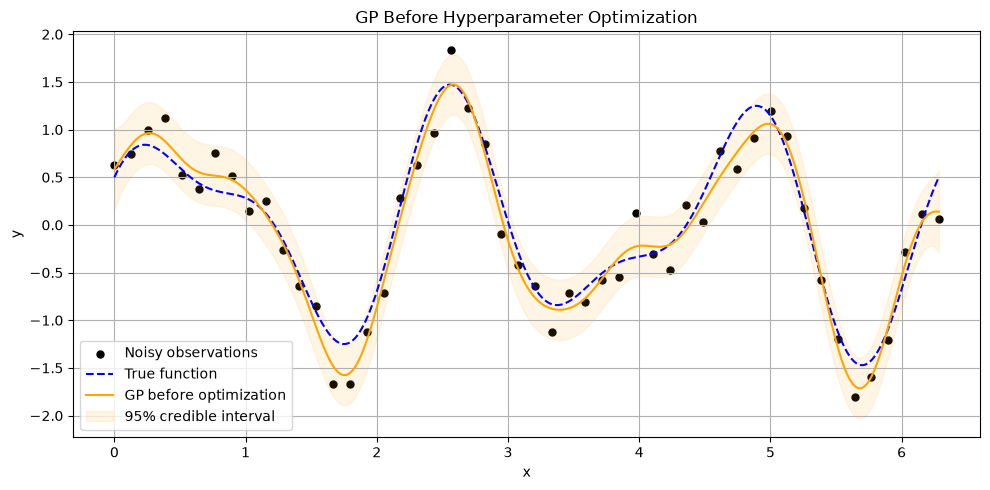

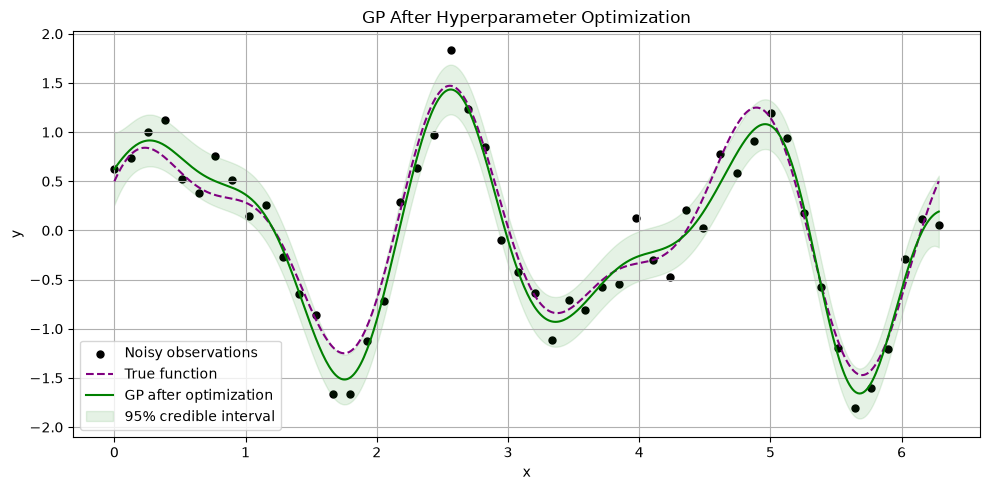

In [3]:
from scipy.optimize import minimize

def negative_log_likelihood(log_params):
    length_scale, sigma_f, sigma_n = np.exp(log_params)
    K = rbf(X_train, X_train, length_scale, sigma_f)
    C_N = K + sigma_n**2 * np.eye(n_samples)
    alpha = np.linalg.solve(C_N, y_train)
    sign, log_det = np.linalg.slogdet(C_N)
    if sign <= 0: 
        return np.inf
    return 0.5 * y_train @ alpha + 0.5 * log_det + 0.5 * n_samples * np.log(2*np.pi)

initial_params = [0.3, 1.0, 0.25]
print("Initial length scale =", initial_params[0])
print("Initial signal std   =", initial_params[1])
print("Initial noise std    =", initial_params[2])

result = minimize(negative_log_likelihood, np.log(initial_params), method="L-BFGS-B")
length_scale_opt, sigma_f_opt, sigma_n_opt = np.exp(result.x)

print("Learned length scale =", length_scale_opt)
print("Learned signal std   =", sigma_f_opt)
print("Learned noise std    =", sigma_n_opt)
print("Negative log likelihood =", result.fun)

mu_before, std_before = gp_predict(X_train, y_train, X_test, *initial_params)
mu_after, std_after = gp_predict(X_train, y_train, X_test, length_scale_opt, sigma_f_opt, sigma_n_opt)

lower_before, upper_before = mu_before - 2.0 * std_before, mu_before + 2.0 * std_before
lower_after, upper_after = mu_after - 2.0 * std_after, mu_after + 2.0 * std_after

# Plot before optimization
plt.figure(figsize=(10,5))
plt.scatter(X_train, y_train, color="black", s=25, label="Noisy observations")
plt.plot(X_test, f(X_test), "--", label="True function", color="Blue")
plt.plot(X_test, mu_before, label="GP before optimization", color="Orange")
plt.fill_between(X_test, lower_before, upper_before, alpha=0.1, label="95% credible interval", color="orange")
plt.xlabel("x")
plt.ylabel("y")
plt.title("GP Before Hyperparameter Optimization")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Plot after optimization
plt.figure(figsize=(10,5))
plt.scatter(X_train, y_train, color="black", s=25, label="Noisy observations")
plt.plot(X_test, f(X_test), "--", label="True function", color="Purple")
plt.plot(X_test, mu_after, label="GP after optimization", color="Green")
plt.fill_between(X_test, lower_after, upper_after, alpha=0.1, label="95% credible interval", color="Green")
plt.xlabel("x")
plt.ylabel("y")
plt.title("GP After Hyperparameter Optimization")
plt.legend()
plt.grid(True)
plt.tight_layout()

## Part B — Expectation-Maximization: Gaussian Mixture Model (20 marks)

### 1. **(10 marks)** Implement the EM algorithm for a Gaussian Mixture Model (GMM) with full covariance matrices.

**GMM using EM Algorithm**

*Step 1:* Let \(X\) contain \(n\) samples with \(d\) features and assume \(K\) Gaussian mixture components.

$$
X\in\mathbb R^{n\times d}
$$

Initialize the mixture weights equally:

$$
\pi_k=\frac{1}{K}
$$

Choose \(K\) initial means randomly from the samples:

$$
\mu_k=X_{\text{random},k}
$$

Initialize each covariance matrix using the covariance of the complete dataset:

$$
\Sigma_k=\operatorname{Cov}(X)
$$

*Step 2:* Initialize the previous log-likelihood as

$$
\mathcal L_{\text{old}}=-\infty
$$

and repeat the following steps for at most `max_iter` iterations.

*Step 3: E-step*

For every sample \($x_i$\) and component \($k$\), calculate the Gaussian probability density:

$$
\mathcal N(x_i|\mu_k,\Sigma_k)
=
\frac{
\exp\left[
-\frac12(x_i-\mu_k)^T
\Sigma_k^{-1}(x_i-\mu_k)
\right]
}{
\sqrt{(2\pi)^d|\Sigma_k|}
}
$$

Calculate the responsibility of component \(k\) for sample \(i\):

$$
\boxed{
\gamma_{ik}
=
\frac{
\pi_k\mathcal N(x_i|\mu_k,\Sigma_k)
}{
\sum_{j=1}^{K}
\pi_j\mathcal N(x_i|\mu_j,\Sigma_j)
}
}
$$

Thus, \($\gamma_{ik}$\) represents the probability that sample \(x_i\) belongs to component \(k\).

*Step 4: M-step*

Calculate the effective number of samples assigned to each component:

$$
N_k=\sum_{i=1}^{n}\gamma_{ik}
$$

Update the mixture weights:

$$
\boxed{
\pi_k=\frac{N_k}{n}
}
$$

Update the mean:

$$
\boxed{
\mu_k=
\frac{1}{N_k}
\sum_{i=1}^{n}\gamma_{ik}x_i
}
$$

Update the covariance:

$$
\boxed{
\Sigma_k=
\frac{1}{N_k}
\sum_{i=1}^{n}
\gamma_{ik}
(x_i-\mu_k)(x_i-\mu_k)^T
}
$$

A small diagonal value is added to the covariance matrix:

$$
\Sigma_k\leftarrow\Sigma_k+10^{-6}I
$$

to prevent singular covariance matrices.

*Step 5: Log-likelihood*

For every sample, calculate the total mixture likelihood:

$$
p(x_i)
=
\sum_{k=1}^{K}
\pi_k\mathcal N(x_i|\mu_k,\Sigma_k)
$$

The log-likelihood is

$$
\boxed{
\mathcal L
=
\sum_{i=1}^{n}\log p(x_i)
}
$$

Store the log-likelihood after every iteration.

*Step 6: Convergence Check*

Stop the EM iterations if the change in log-likelihood is smaller than the tolerance:

$$
|\mathcal L-\mathcal L_{\text{old}}|<\text{tol}
$$

Otherwise, update

$$
\mathcal L_{\text{old}}\leftarrow\mathcal L
$$

and continue to the next iteration.

*Step 7: Cluster Assignment*

After convergence, assign each sample to the component with the maximum responsibility:

$$
\boxed{
\text{label}_i
=
\arg\max_k\gamma_{ik}
}
$$

*Step 8:* Return the learned mixture weights \($\pi$\), means \($\mu$\), covariance matrices \($\Sigma$\), responsibilities \($\gamma$\), cluster labels, and log-likelihood values.


In [4]:
def gmm_em(X, n_components, max_iter=100, tol=1e-6):
    n_samples, n_features = X.shape

    # Initialize parameters
    pi = np.ones(n_components) / n_components
    mu = X[np.random.choice(n_samples, n_components, replace=False)]
    Sigma = np.array([np.cov(X.T) for _ in range(n_components)])

    log_likelihoods = []
    log_likelihood_old = -np.inf

    for iteration in range(max_iter):
        # E-step
        responsibilities = np.zeros((n_samples, n_components))

        for k in range(n_components):
            diff = X - mu[k]
            inv_Sigma = np.linalg.inv(Sigma[k])
            det_Sigma = np.linalg.det(Sigma[k])
            exponent = -0.5 * np.sum((diff @ inv_Sigma) * diff, axis=1)
            denominator = np.sqrt((2 * np.pi) ** n_features * det_Sigma)
            responsibilities[:, k] = pi[k] * np.exp(exponent) / denominator

        responsibilities /= np.sum(responsibilities, axis=1, keepdims=True)

        # M-step
        Nk = np.sum(responsibilities, axis=0)

        for k in range(n_components):
            pi[k] = Nk[k] / n_samples
            mu[k] = np.sum(responsibilities[:, k, None] * X, axis=0) / Nk[k]
            diff = X - mu[k]
            Sigma[k] = (responsibilities[:, k, None] * diff).T @ diff / Nk[k]
            Sigma[k] += 1e-6 * np.eye(n_features)   # Prevent singular covariance matrix

        # Log-likelihood
        likelihood = np.zeros(n_samples)

        for k in range(n_components):
            diff = X - mu[k]
            inv_Sigma = np.linalg.inv(Sigma[k])
            det_Sigma = np.linalg.det(Sigma[k])
            exponent = -0.5 * np.sum((diff @ inv_Sigma) * diff, axis=1)
            denominator = np.sqrt((2 * np.pi) ** n_features * det_Sigma)
            likelihood += pi[k] * np.exp(exponent) / denominator

        log_likelihood = np.sum(np.log(likelihood + 1e-12))
        log_likelihoods.append(log_likelihood)

        # Check convergence
        if abs(log_likelihood - log_likelihood_old) < tol:
            break
        log_likelihood_old = log_likelihood

    # Assign the label which maximizes responsibility
    labels = np.argmax(responsibilities, axis=1)

    return pi, mu, Sigma, responsibilities, labels, log_likelihoods

### 2. **(10 marks)** Apply your GMM to the [Iris dataset](https://scikit-learn.org/1.5/auto_examples/datasets/plot_iris_dataset.html)  Compare clustering results to kmeans. Plot log-likelihood across iterations and analyze convergence.

**GMM and K-means Clustering on Iris Dataset**

*Step 1:* Load the Iris dataset.

$$
X=\text{Iris feature matrix}
$$

$$
y_{\text{true}}=\text{actual class labels}
$$

The dataset contains 150 samples with 4 features. Since there are 3 classes, use 3 mixture components for GMM and 3 clusters for K-means.

*Step 2:* Apply the GMM-EM algorithm with

$$
K=3,\qquad
\text{max\_iter}=100,\qquad
\text{tol}=10^{-6}
$$

The algorithm estimates:

$$
\pi_k,\quad \mu_k,\quad \Sigma_k
$$

and calculates the responsibilities

$$
\gamma_{ik}.
$$

Each sample is assigned to the component with maximum responsibility:

$$
\text{GMM label}_i=\arg\max_k\gamma_{ik}.
$$

*Step 3:* Apply K-means clustering with 3 clusters.

K-means minimizes the within-cluster sum of squared distances:

$$
\boxed{
J=\sum_{k=1}^{K}\sum_{x_i\in C_k}
\|x_i-\mu_k\|^2
}
$$

The resulting cluster assignments are stored as `kmeans_labels`.

*Step 4:* Compare the clustering results using the Adjusted Rand Index (ARI).

ARI measures the agreement between two cluster assignments while correcting for agreement occurring by chance.

Compute:

$$
\text{ARI}_{\text{GMM,true}}
=
\operatorname{ARI}(y_{\text{true}},y_{\text{GMM}})
$$

$$
\text{ARI}_{\text{KMeans,true}}
=
\operatorname{ARI}(y_{\text{true}},y_{\text{KMeans}})
$$

and

$$
\text{ARI}_{\text{GMM,KMeans}}
=
\operatorname{ARI}(y_{\text{GMM}},y_{\text{KMeans}})
$$

An ARI close to \($1$\) indicates strong agreement, while an ARI close to \($0$\) indicates agreement approximately at the level expected by chance.

*Step 5:* Plot the GMM log-likelihood against the EM iteration number.

$$
\mathcal L^{(t)}
=
\sum_{i=1}^{n}
\log
\left[
\sum_{k=1}^{K}
\pi_k
\mathcal N(x_i|\mu_k,\Sigma_k)
\right]
$$

The plot shows the convergence behavior of the EM algorithm. The log-likelihood should generally increase and eventually stabilize.

*Step 6:* Visualize the GMM clustering using the first two features of the Iris dataset.

Plot:

$$
x=\text{Sepal length}
$$

$$
y=\text{Sepal width}
$$

and represent each sample according to its GMM cluster label.

*Step 7:* Visualize the K-means clustering using the same two features.

Use Sepal length and Sepal width as the two axes and represent each sample according to its K-means cluster label.

*Step 8:* Compare the two clustering methods using their ARI values and their corresponding cluster visualizations.


Adjusted Rand Index (ARI) metric
GMM vs True labels     = 0.5306358340260213
K-means vs True labels = 0.7302382722834697
GMM vs K-means         = 0.551561229687677


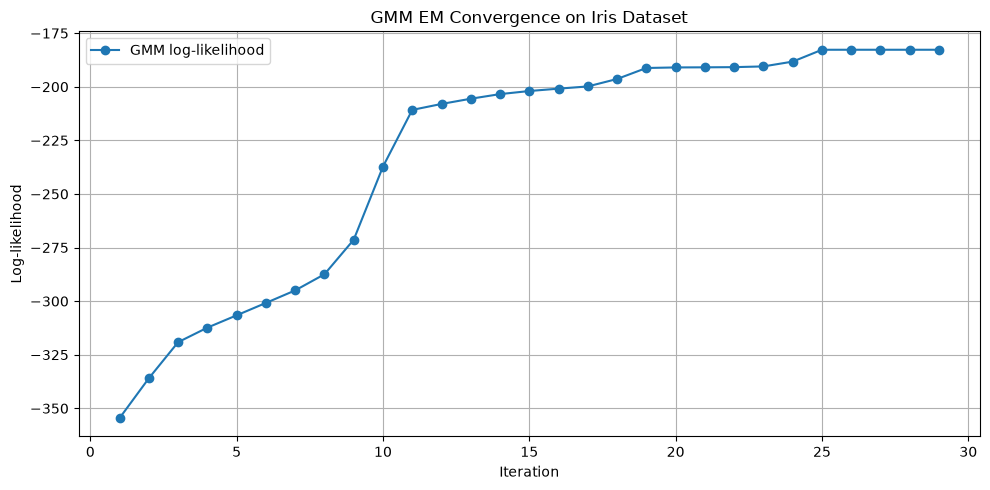

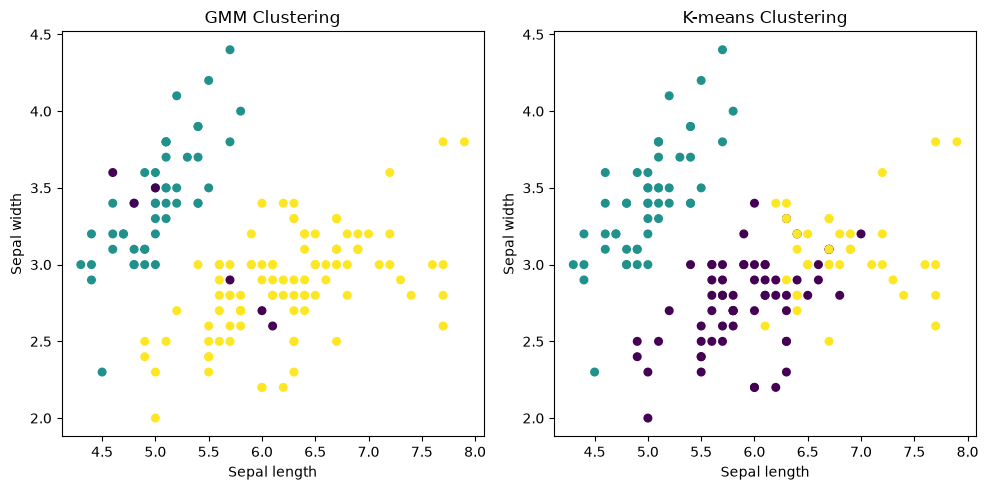

In [5]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Load Iris dataset
iris = load_iris()
X = iris.data
y_true = iris.target

# Apply GMM
pi, mu, Sigma, responsibilities, gmm_labels, log_likelihoods = gmm_em(X, n_components=3, max_iter=100, tol=1e-6)

# Apply K-means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

# Compare clustering results
print("Adjusted Rand Index (ARI) metric")
print("GMM vs True labels     =", adjusted_rand_score(y_true, gmm_labels))
print("K-means vs True labels =", adjusted_rand_score(y_true, kmeans_labels))
print("GMM vs K-means         =", adjusted_rand_score(gmm_labels, kmeans_labels))

# Plot log-likelihood convergence
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(log_likelihoods) + 1), log_likelihoods, marker="o", label="GMM log-likelihood")
plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
plt.title("GMM EM Convergence on Iris Dataset")
plt.grid(True)
plt.legend()
plt.tight_layout()

# Plot clustering results for GMM using first two features
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=gmm_labels, s=30)
plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("GMM Clustering")

# Plot clustering results for K-means using first two features
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, s=30)
plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("K-means Clustering")
plt.tight_layout()

**Observations**

On the Iris dataset, both GMM and K-means produced ***reasonably good clustering***, against the true species labels. The GMM and K-means clusterings themselves had ***moderate agreement but different assignments for some samples***. GMM additionally models ***cluster covariance*** and provides ***soft probabilistic assignments***.

## Part C — EM for Bayesian Linear Regression

### 1. **(10 marks)** Implement EM updates to estimate the prior precision $λ$ and noise precision $β$ for Bayesian linear regression.

**Bayesian Linear Regression using EM**

*Step 1:* Assume the Bayesian linear regression model

$$
y=Xw+\epsilon
$$

where

$$
\epsilon\sim\mathcal N(0,\beta^{-1}I)
$$

and the prior distribution of the weights is

$$
w\sim\mathcal N(0,\lambda^{-1}I).
$$

Here, \($\lambda$\) is the prior precision and \($\beta$\) is the noise precision.

*Step 2:* Initialize the precision parameters

$$
\lambda=1,\qquad\beta=1
$$

and initialize the histories for storing their values and the evidence.

*Step 3: E-step*

Compute the posterior covariance of \(w\):

$$
\boxed{
S=
\left(
\lambda I+\beta X^TX
\right)^{-1}
}
$$

Compute the posterior mean:

$$
\boxed{
m=\beta S X^Ty
}
$$

Therefore,

$$
p(w|X,y)
=
\mathcal N(w|m,S).
$$

*Step 4: M-step*

Update the prior precision \(\lambda\):

$$
\boxed{
\lambda_{\text{new}}
=
\frac{d}
{\operatorname{tr}(S)+m^Tm}
}
$$

where \(d\) is the number of features.

The denominator represents the expected squared magnitude of the weight vector:

$$
E[w^Tw]
=
\operatorname{tr}(S)+m^Tm.
$$

*Step 5:* Compute the expected squared prediction error:

$$
E_{\text{error}}
=
y^Ty
-2y^TXm
+
\operatorname{tr}
\left[
X(S+mm^T)X^T
\right].
$$

Equivalently,

$$
E_{\text{error}}
=
\|y-Xm\|^2+\operatorname{tr}(X^TXS).
$$

*Step 6:* Update the noise precision:

$$
\boxed{
\beta_{\text{new}}
=
\frac{n}
{E_{\text{error}}}
}
$$

where \(n\) is the number of training samples.

*Step 7: Evidence calculation*

The marginal distribution of \(y\) is

$$
p(y|X)
=
\mathcal N(0,C_N)
$$

where

$$
\boxed{
C_N=
\frac{1}{\beta}I+
\frac{1}{\lambda}XX^T
}
$$

Using the updated precision parameters, compute

$$
\log p(y|X)
=
-\frac12
\left[
n\log(2\pi)
+\log|C_N|
+y^TC_N^{-1}y
\right].
$$

This value is stored at every iteration to monitor the convergence of the model evidence.

*Step 8: Convergence Check*

Stop the EM iterations when both precision parameters have changed by less than the tolerance:

$$
|\lambda_{\text{new}}-\lambda|<\text{tol}
$$

and

$$
|\beta_{\text{new}}-\beta|<\text{tol}.
$$

Otherwise, update

$$
\lambda\leftarrow\lambda_{\text{new}},
\qquad
\beta\leftarrow\beta_{\text{new}}
$$

and continue to the next iteration.

*Step 9:* After convergence, return the posterior mean \($m$\), posterior covariance \($S$\), learned precision parameters \($\lambda$, $\beta$\), their iteration histories, and the evidence history.


In [6]:
def em_bayesian_linear_regression(X, y, max_iter=100, tol=1e-6):
    n_samples, n_features = X.shape

    # Initialize precision parameters
    lambdaa = 1.0
    beta = 1.0

    # Store values across iterations
    lambda_history = []
    beta_history = []
    evidence_history = []

    for iteration in range(max_iter):
        # E-step: posterior covariance and mean of w
        S = np.linalg.inv(lambdaa * np.eye(n_features) + beta * X.T @ X)
        m = beta * S @ X.T @ y

        # M-step: update lambda and beta
        lambdaa_new = n_features / (np.trace(S) + m @ m)
        E_error = (y @ y - 2 * y @ X @ m + np.trace(X @ (S + np.outer(m, m)) @ X.T))
        beta_new = n_samples / E_error

        # Calculate log-marginal likelihood
        C_N = (np.eye(n_samples) / beta_new + X @ X.T / lambdaa_new)
        sign, log_det = np.linalg.slogdet(C_N)
        alpha = np.linalg.solve(C_N, y)
        log_evidence = -0.5 * (n_samples * np.log(2 * np.pi) + log_det + y @ alpha)

        # Store values
        lambda_history.append(lambdaa_new)
        beta_history.append(beta_new)
        evidence_history.append(log_evidence)

        # Check convergence
        if (abs(lambdaa_new - lambdaa) < tol and abs(beta_new - beta) < tol):
            lambdaa = lambdaa_new
            beta = beta_new
            break

        lambdaa = lambdaa_new
        beta = beta_new

    return m, S, lambdaa, beta, lambda_history, beta_history, evidence_history

### 2. **(10 marks)** Apply your method to a regression dataset, for example generated with `sklearn.datasets.make_regression`, with transformed features into polynomial terms (e.g., degree 3 or 4 using PolynomialFeatures from scikit-learn). Plot the evidence (log-marginal likelihood) across iterations and discuss how $λ$ and $β$ evolve.

**Bayesian Polynomial Regression using EM**

*Step 1:* Generate a regression dataset with 100 samples and one input feature.

$$
X\in\mathbb R^{100\times1}
$$

The target values \(y\) are generated using a linear relationship with Gaussian noise.

*Step 2:* Transform the input into polynomial features of degree 3.

$$
X_{\text{poly}}
=
[1,X,X^2,X^3]
$$

Thus, for each input \(x\),

$$
\phi(x)=[1,x,x^2,x^3].
$$

The polynomial feature matrix has four columns:

$$
X_{\text{poly}}\in\mathbb R^{100\times4}.
$$

*Step 3:* Apply the EM algorithm for Bayesian linear regression to \(X_{\text{poly}}\) and \(y\).

Initialize

$$
\lambda=1,\qquad\beta=1.
$$

*Step 4: E-step*

Compute the posterior covariance:

$$
S=
\left(
\lambda I+\beta X_{\text{poly}}^TX_{\text{poly}}
\right)^{-1}
$$

and posterior mean:

$$
m=
\beta S X_{\text{poly}}^Ty.
$$

Hence,

$$
p(w|X,y)=\mathcal N(w|m,S).
$$

*Step 5: M-step*

Update the prior precision:

$$
\lambda_{\text{new}}
=
\frac{d}
{\operatorname{tr}(S)+m^Tm}
$$

where \(d=4\) is the number of polynomial features.

Compute the expected squared error:

$$
E_{\text{error}}
=
y^Ty
-2y^TX_{\text{poly}}m
+
\operatorname{tr}
\left[
X_{\text{poly}}
(S+mm^T)
X_{\text{poly}}^T
\right].
$$

Update the noise precision:

$$
\beta_{\text{new}}
=
\frac{n}{E_{\text{error}}}
$$

where \(n=100\).

*Step 6: Evidence Calculation*

Construct the covariance matrix

$$
C_N=
\frac{1}{\beta_{\text{new}}}I
+
\frac{1}{\lambda_{\text{new}}}
X_{\text{poly}}X_{\text{poly}}^T.
$$

Calculate the log-marginal likelihood:

$$
\log p(y|X)
=
-\frac12
\left[
n\log(2\pi)
+\log|C_N|
+y^TC_N^{-1}y
\right].
$$

Store the evidence after every EM iteration.

*Step 7: Convergence*

Repeat the E-step and M-step until

$$
|\lambda_{\text{new}}-\lambda|<10^{-6}
$$

and

$$
|\beta_{\text{new}}-\beta|<10^{-6},
$$

or until the maximum number of iterations is reached.

*Step 8:* Report the learned values

$$
\lambda_{\text{learned}}=\lambda
$$

and

$$
\beta_{\text{learned}}=\beta.
$$

*Step 9:* Plot the log-marginal likelihood against the EM iteration number to observe the evolution of the model evidence.

*Step 10:* Plot the values of \($\lambda$\) and \($\beta$\) against the EM iteration number to observe the convergence of the prior and noise precision parameters.


Learned lambda = 0.002059162929750419
Learned beta   = 0.012299819933395316


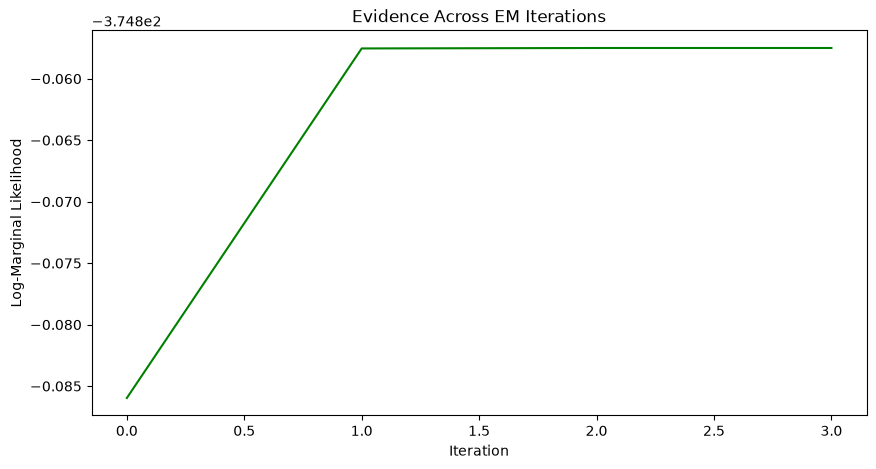

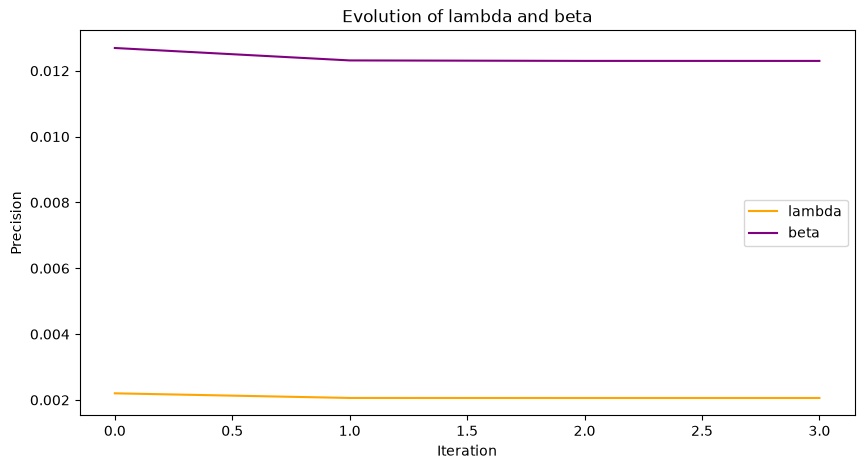

In [7]:
from sklearn.datasets import make_regression
from sklearn.preprocessing import PolynomialFeatures

# Generate dataset
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

# Polynomial features
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

# Apply EM
m, S, lambdaa, beta, lambda_history, beta_history, evidence_history = em_bayesian_linear_regression(X_poly, y)

print("Learned lambda =", lambdaa)
print("Learned beta   =", beta)

# Plot evidence
plt.figure(figsize=(10,5))
plt.plot(evidence_history, color="green")
plt.xlabel("Iteration")
plt.ylabel("Log-Marginal Likelihood")
plt.title("Evidence Across EM Iterations")
plt.show()

# Plot lambda and beta
plt.figure(figsize=(10,5))
plt.plot(lambda_history, label="lambda", color="orange")
plt.plot(beta_history, label="beta", color="purple")
plt.xlabel("Iteration")
plt.ylabel("Precision")
plt.title("Evolution of lambda and beta")
plt.legend()
plt.show()

## Part D — Variational Inference

### 1. Mean-Field VI with the Reparameterization Trick (20 marks)

Implement Mean-Field Variational Inference with the Reparameterization Trick.
Assume a mean-field Gaussian approximation:

$$
q(w)=\mathcal{N}\left(w\mid\mu,\operatorname{diag}(\sigma^2)\right).
$$

Use the reparameterization trick:

$$
w=\mu+\sigma\odot\epsilon,
\qquad
\epsilon\sim\mathcal{N}(0,I).
$$

Optimize the Evidence Lower Bound (ELBO) using gradient ascent with PyTorch.


**Mean-Field Variational Inference**

*Input:* Training data \($X,y$\), maximum iterations \($T$\), learning rate \($\eta$\).

*Output:* Variational mean \($\mu$\), standard deviation \($\sigma$\), and ELBO history.

**1. Initialization**

* Let \($X\in\mathbb{R}^{N\times D}$\), where \($N$\) is the number of samples and \($D$\) is the number of features.
* Initialize the variational parameters:
  \($\mu=\mathbf{0},\qquad \log\sigma=\mathbf{0}.$\)
* Define the mean-field variational distribution:
  \($q(w)=\mathcal{N}(w\mid\mu,\operatorname{diag}(\sigma^2)).$\)
* Set the prior:
  \($p(w)=\mathcal{N}(w\mid\mu_0,\operatorname{diag}(\sigma_0^2)),$\)
  where \(\mu_0=\mathbf{0}\) and \(\sigma_0=\mathbf{1}\).

**2. Reparameterization**

*For each iteration:*

* Compute the standard deviation:
  \($\sigma=\exp(\log\sigma).$\)
* Sample
  \($\epsilon\sim\mathcal{N}(0,I).$\)
* Reparameterize the weights as
  \($w=\mu+\sigma\odot\epsilon.$\)

**3. Compute the Log-Likelihood**

*For binary logistic regression:*

* Compute the logits:
  \($z=Xw.$\)
* The log-likelihood is

  $$
  \log p(y\mid X,w)
  =-\operatorname{BCEWithLogits}(z,y).
  $$

**4. Compute the Log-Prior**

$$
\log p(w)
=
-\frac{1}{2}
\sum_{j=1}^{D}
\frac{(w_j-\mu_{0j})^2}{\sigma_{0j}^2}.
$$

**5. Compute the Entropy**

*For the diagonal Gaussian variational distribution:*

$$
H(q)=\sum_{j=1}^{D}\log\sigma_j
$$

*ignoring constants independent of the variational parameters.*

**6. Compute the ELBO**

$$
\mathcal{L}
=
\log p(y\mid X,w)
+
\log p(w)
+
H(q).
$$

**7. Optimize the ELBO**

* Define the loss:
  \($\text{Loss}=-\mathcal{L}.$\)
* Compute gradients of the loss with respect to \($\mu$\) and \($\log\sigma$\).
* Update \($\mu$\) and \($\log\sigma$\) using Adam.
* Store the ELBO value for each iteration.

**8. Repeat**

*Repeat Steps 2–7 for ($T$) iterations until the variational parameters converge.*

**9. Prediction**

*For a test sample \($x$\):*

* Draw \($S$\) weight samples from the learned variational posterior:

  $$
  w^{(s)}=\mu+\sigma\odot\epsilon^{(s)},\qquad
  \epsilon^{(s)}\sim\mathcal{N}(0,I).$$
  $$
* Compute the probability for each sample:
  \($p^{(s)}=\operatorname{sigmoid}(x^Tw^{(s)}).$\)
* Average the probabilities:

  $$
  \hat p(y=1\mid x)
  \approx
  \frac{1}{S}\sum_{s=1}^{S}p^{(s)}.$$
  $$

*The final probability is converted to a class prediction using a threshold of \($0.5$\).*


In [11]:
import torch

def mean_field_vi(X, y, max_iter=1000, lr=0.01):
    """
    Fit Mean field VI
    """
    n_samples, n_features = X.shape

    # Convert data to tensors
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)

    # Initialize variational parameters
    mu = torch.zeros(n_features, requires_grad=True)
    log_sigma = torch.zeros(n_features, requires_grad=True)

    # Prior parameters
    prior_mu = torch.zeros(n_features)
    prior_sigma = torch.ones(n_features)

    # Optimizer
    optimizer = torch.optim.Adam([mu, log_sigma], lr=lr)
    elbo_history = []

    for iteration in range(max_iter):
        optimizer.zero_grad()

        # Standard deviation
        sigma = torch.exp(log_sigma)

        # Reparameterization trick
        epsilon = torch.randn_like(sigma)
        w = mu + sigma * epsilon

        # Compute ELBO
        logits = X @ w
        log_likelihood = -torch.nn.functional.binary_cross_entropy_with_logits(logits, y, reduction="sum")
        log_prior = -0.5 * torch.sum((w - prior_mu) ** 2 / prior_sigma ** 2)    
        entropy = torch.sum(log_sigma)                                          
        elbo = log_likelihood + log_prior + entropy                             

        # Gradient ascent using gradient descent on -ELBO
        loss = -elbo
        loss.backward()
        optimizer.step()
        elbo_history.append(elbo.item())

    return mu.detach(), torch.exp(log_sigma).detach(), elbo_history


def predict_vi(X, mu, sigma, n_samples=100):
    """
    VI prediction using posterior samples
    """
    X = torch.tensor(X, dtype=torch.float32)

    with torch.no_grad():
        probabilities = []
        for _ in range(n_samples):
            epsilon = torch.randn_like(sigma)
            w = mu + sigma * epsilon
            probabilities.append(torch.sigmoid(X @ w))

        return torch.stack(probabilities).mean(dim=0).numpy()

### 2. Experiments (20 marks)

Run experiments with the following setup:
- Dataset: Use `sklearn.datasets.make_classification` on a binary subset of the digits dataset.
- Plot the ELBO as a function of iteration.
- Evaluate predictive accuracy and calibration using the Brier score on a held-out test set.
- Compare the results to standard MAP logistic regression (e.g., `scikit-learn’s LogisticRegression`).


**Experiment — VI vs MAP Logistic Regression**

***Input:*** Binary digits dataset, number of VI iterations \(T\), learning rate \(\eta\), and number of posterior samples \(S\).

***Output:*** VI and MAP accuracy, Brier scores, and ELBO plot.

**1. Load the Binary Digits Dataset**

* Load the digits dataset.
* Select only samples whose labels are 0 or 1:

$$
\text{mask}=(y_{\text{digits}}=0)\lor(y_{\text{digits}}=1).
$$

* Obtain the corresponding feature matrix \($X_{\text{digits}}$\) and labels \($y_{\text{digits}}$\).

**2. Generate the Classification Dataset**

* Generate a binary classification dataset using `make_classification`.

* Set:

$$
N=\text{number of samples in the binary digits subset},
$$

$$
D=\text{number of features in the digits dataset}.
$$

* Use 20 informative features, 5 redundant features, and 2 classes.
* Set the random state to 42 for reproducibility.

**3. Train-Test Split**

* Split the generated dataset into training and testing sets.
* Use 80% of the data for training and 20% for testing.
* Use stratified sampling to preserve the class distribution.

**4. Train Mean-Field VI**

* Apply the Mean-Field Variational Inference algorithm to the training data.
* Optimize the variational parameters \($\mu$\) and \($\log\sigma$\) for \($T=1000$\) iterations using learning rate \($\eta=0.01$\).
* Store the ELBO value at every iteration.

**5. VI Prediction**

* Draw \($S=100$\) samples from the learned variational posterior:

$$
w^{(s)}
=
\mu+\sigma\odot\epsilon^{(s)},
\qquad
\epsilon^{(s)}\sim\mathcal{N}(0,I).
$$

* For every sampled weight vector, compute

$$
p^{(s)}
=
\operatorname{sigmoid}(X_{\text{test}}w^{(s)}).
$$

* Average the probabilities:

$$
\hat p_{\text{VI}}
=
\frac{1}{S}
\sum_{s=1}^{S}p^{(s)}.
$$

* Convert probabilities into class predictions using threshold \(0.5\):

$$
\hat y_{\text{VI}}
=
\begin{cases}
1,&\hat p_{\text{VI}}\geq0.5,\\
0,&\text{otherwise}.
\end{cases}
$$

**6. Train MAP Logistic Regression**

* Train standard Logistic Regression using the training data.
* Use \($C=1.0$\) and maximum 1000 iterations.
* Obtain the predicted probability of class 1:

$$
\hat p_{\text{MAP}}
=
P(y=1\mid X_{\text{test}}).
$$

* Convert the probabilities into class predictions using threshold \($0.5$\).

**7. Evaluate Accuracy**

* Compute the accuracy for both models:

$$
\text{Accuracy}
=
\frac{\text{Number of correct predictions}}{\text{Total number of predictions}}.
$$

* Compare:

$$
\text{Accuracy}_{\text{VI}}
\quad\text{vs.}\quad
\text{Accuracy}_{\text{MAP}}.
$$

**8. Evaluate Calibration Using Brier Score**

* Compute the Brier score for each model:
$$
\text{Brier Score}
=
\frac{1}{N_{\text{test}}}
\sum_{i=1}^{N_{\text{test}}}
(p_i-y_i)^2.
$$

* A lower Brier score indicates better probabilistic calibration.
* Compare:

$$
\text{Brier}_{\text{VI}}
\quad\text{vs.}\quad
\text{Brier}_{\text{MAP}}.
$$

**9. Plot ELBO**

* Plot the ELBO value against the iteration number.
* The plot is used to observe whether the variational optimization converges.

**10. Report the Results**

* Report the accuracy and Brier score of both models in a comparison table.
* A higher accuracy indicates better classification performance.
* A lower Brier score indicates better probabilistic calibration.
* Compare the ELBO curve to determine whether the VI optimization converges during training.



COMPARISON
Model		Accuracy	Brier Score
VI		0.7639		0.1946
MAP		0.7361		0.2025


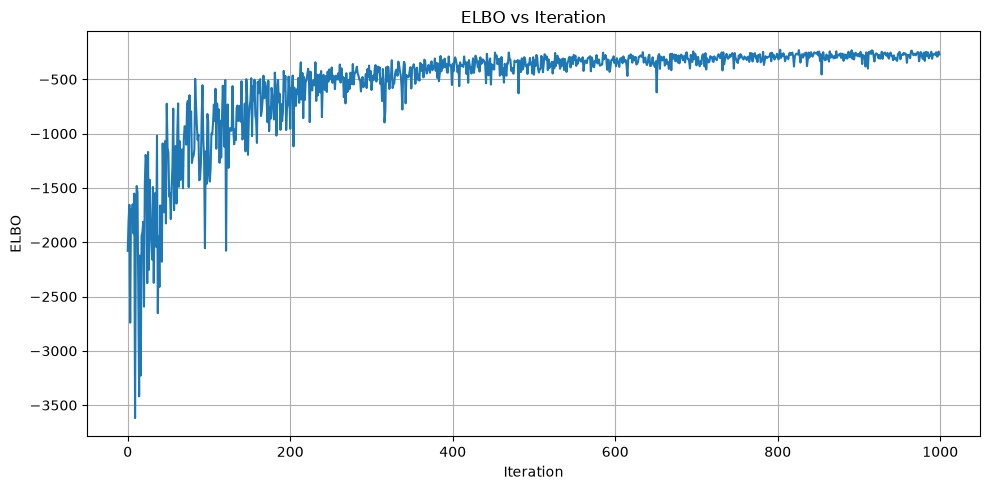

In [17]:
from sklearn.datasets import load_digits, make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss

# Load binary subset of digits dataset
digits = load_digits()
mask = (digits.target == 0) | (digits.target == 1)
X_digits = digits.data[mask]
y_digits = digits.target[mask]

# Generate classification dataset using the binary digits subset
X, y = make_classification(
    n_samples=len(y_digits), n_features=X_digits.shape[1], n_informative=20, n_redundant=5, n_classes=2, random_state=42
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Mean-Field VI
mu, sigma, elbo_history = mean_field_vi(X_train, y_train, max_iter=1000, lr=0.01)

# VI predictions
vi_prob = predict_vi(X_test, mu, sigma, n_samples=100)
vi_pred = (vi_prob >= 0.5).astype(int)

# MAP Logistic Regression
map_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
map_model.fit(X_train, y_train)

# MAP predictions
map_prob = map_model.predict_proba(X_test)[:, 1]
map_pred = (map_prob >= 0.5).astype(int)

# Evaluation
vi_accuracy = accuracy_score(y_test, vi_pred)
map_accuracy = accuracy_score(y_test, map_pred)
vi_brier = brier_score_loss(y_test, vi_prob)
map_brier = brier_score_loss(y_test, map_prob)

# Show comparison results
print("\nCOMPARISON")
print("Model\t\tAccuracy\tBrier Score")
print(f"VI\t\t{vi_accuracy:.4f}\t\t{vi_brier:.4f}")
print(f"MAP\t\t{map_accuracy:.4f}\t\t{map_brier:.4f}")

# Plot ELBO
plt.figure(figsize=(10, 5))
plt.plot(elbo_history)
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.title("ELBO vs Iteration")
plt.grid(True)
plt.tight_layout()

**Observations**
- Mean-Field VI achieved ***better accuracy*** than MAP Logistic Regression.
- VI also achieved a ***lower Brier score***, indicating better probabilistic calibration on the test set.

---
End of the assignment